# Advance 3 - Business Analysis & Visualizations

## Table of Contents

1. Population Distribution by City
2. Socioeconomic Status Distribution
3. Average Restaurant Spending by City
4. Visit Frequency vs Restaurant Spending
5. Monthly Income vs Restaurant Spending
6. Food Preferences by City
7. High-Spending Customer Profile
8. Premium Memberships by City
9. Alcohol Consumption by Age Group
10. Final Conclusions

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
#call the csv clean 

customers_clean_df = pd.read_csv(
    "../data/customers_clean.csv"
)

customers_clean_df.head()

,id_persona,nombre,apellido,edad,genero,ciudad_residencia,estrato_socioeconomico,frecuencia_visita,promedio_gasto_comida,ocio,consume_licor,preferencias_alimenticias,membresia_premium,telefono_contacto,correo_electronico,tipo_de_pago_mas_usado,ingresos_mensuales
0,2550327378,Jackson,Gomez,31.0,Masculino,Miami,Alto,6.0,67.51,Sí,No,Vegetariano,Sí,(830)220-1926,NaN,Efectivo,6425
1,9446112038,Samantha,Soto,40.0,Femenino,Denver,Medio,2.0,44.92,Sí,Sí,Mariscos,No,881-476-1426,NaN,Efectivo,2374
2,3098363243,Terry,Adams,62.0,Femenino,Denver,Bajo,2.0,9.24,Sí,Sí,Vegetariano,No,NaN,diana74@example.net,Efectivo,1110
3,4013002847,James,Shannon,41.0,Masculino,Boston,Alto,5.0,30.74,Sí,Sí,Carnes,Sí,NaN,scottfrey@example.com,Tarjeta,6931
4,7372911048,Susan,Jones,49.0,Femenino,San Diego,Bajo,0.0,0.00,No,No,Carnes,No,243.248.8919,glassgary@example.org,Tarjeta,1350


# Categorical Variables

## Summary

In this stage of the Exploratory Data Analysis (EDA), the categorical variables of the customer dataset were analyzed to better understand the characteristics and distribution of the customer base

The analysis included the following variables:

- Gender
- Dietary Preferences
- City of Residence
- Alcohol Consumption
- Premium Membership
- Preferred Payment Method
- Socioeconomic Status
- Leisure Activities

# Numerical Variables

## Summary

In this stage of the Exploratory Data Analysis (EDA), the numerical variables of the customer dataset were analyzed to understand their distribution, identify potential data quality issues, and obtain descriptive statistics

The analysis included the following variables:

- Age
- Visit Frequency
- Average Food Spending
- Monthly Income


In [3]:
city_counts = customers_clean_df["ciudad_residencia"].value_counts()      

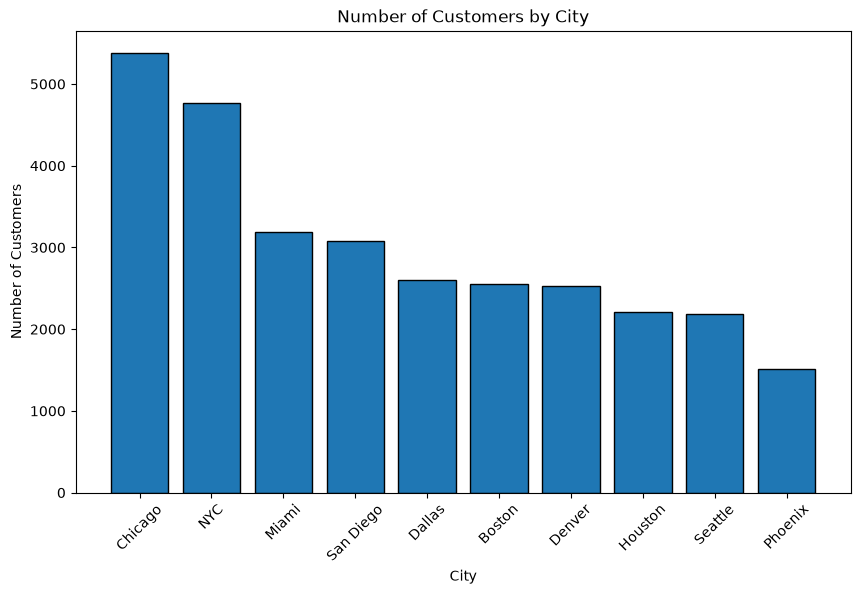

In [4]:
plt.figure(figsize=(10,6))

plt.bar(city_counts.index, city_counts.values, edgecolor="black")

plt.title("Number of Customers by City")
plt.xlabel("City")
plt.ylabel("Number of Customers")

plt.xticks(rotation=45)

plt.show()

# Customer Distribution by City

## Business Question

How are customers distributed across the different cities?

## Business Value

Understanding the distribution of customers by city helps identify where the company has the largest customer base. This information can be used to prioritize marketing campaigns, optimize resource allocation, and design specific strategies for cities with lower customer presence.

## Visualization

The following bar chart shows the number of registered customers in each city.

## Interpretation

The highest concentration of customers is located in **Chicago** and **NYC**, making them the cities with the largest customer base. The remaining cities show a more balanced distribution, with no major differences in the number of registered customers.

## Business Insight

The company can prioritize marketing campaigns and customer retention strategies in Chicago and NYC while developing acquisition campaigns in cities with lower customer presence to achieve a more balanced market distribution.

In [5]:
socioeconomic_counts = customers_clean_df["estrato_socioeconomico"].value_counts()

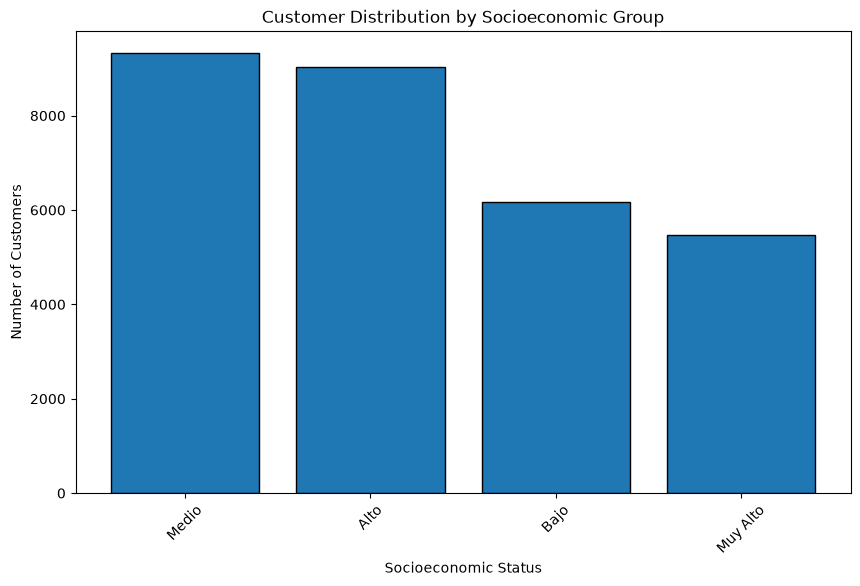

In [6]:
plt.figure(figsize=(10,6))

plt.bar(socioeconomic_counts.index, socioeconomic_counts.values, edgecolor="black")

plt.title("Customer Distribution by Socioeconomic Group")
plt.xlabel("Socioeconomic Status")
plt.ylabel("Number of Customers")

plt.xticks(rotation=45)

plt.show()

# Customer Distribution by Socioeconomic Status

## Business Question

How are customers distributed across different socioeconomic groups?

## Business Value

Understanding the socioeconomic distribution of customers helps the company identify different purchasing power segments. This information supports the design of targeted marketing campaigns, personalized promotions, and loyalty strategies adapted to the characteristics and needs of each customer group.

## Visualization

The following bar chart illustrates the distribution of customers according to their socioeconomic status.

## Interpretation

The bar chart shows that the largest proportion of customers belongs to the **Middle** and **High** socioeconomic groups, making them the most representative segments of the customer base. In contrast, the **Low** and **Very High** socioeconomic groups contain fewer customers, although the difference between these two groups is relatively small.

## Business Insight

The company can develop differentiated marketing strategies according to the socioeconomic profile of its customers. Since most customers belong to the **Middle** and **High** socioeconomic groups, these segments should be prioritized for promotions, loyalty programs, and advertising campaigns. Additionally, the **Low** and **Very High** socioeconomic groups represent valuable market segments that can benefit from more personalized strategies based on their purchasing behavior and specific needs.

### Statistical Summary

In [7]:
average_spending_by_city = (
    customers_clean_df
    .groupby("ciudad_residencia")["promedio_gasto_comida"]
    .mean()
    .sort_values(ascending=False)
)

average_spending_by_city

ciudad_residencia
Miami        39.749670
NYC          37.084238
Seattle      36.809973
Phoenix      36.486347
San Diego    34.709463
Denver       34.218989
Boston       29.485379
Dallas       28.676875
Houston      26.017789
Chicago      25.531640
Name: promedio_gasto_comida, dtype: float64

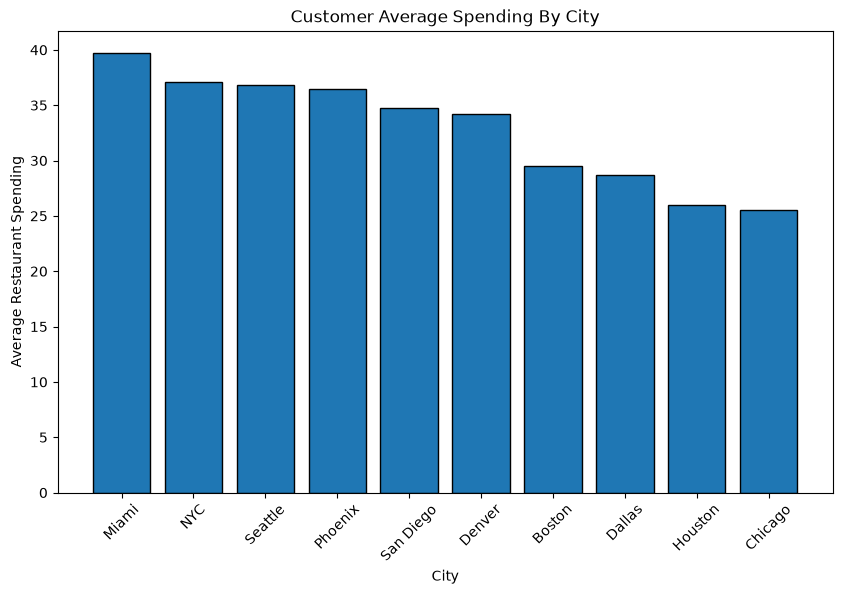

In [8]:
plt.figure(figsize=(10,6))

plt.bar(average_spending_by_city.index, average_spending_by_city.values, edgecolor="black")

plt.title("Customer Average Spending By City")
plt.xlabel("City")
plt.ylabel("Average Restaurant Spending")

plt.xticks(rotation=45)

plt.show()

# Customer Average Spending by City

## Business Question

Which city has the highest average restaurant spending?

## Business Value

Understanding the average customer spending by city helps identify markets where customers generate higher revenue. This information supports decisions related to pricing strategies, promotional campaigns, resource allocation, and investment opportunities across different locations.

## Visualization

The following bar chart shows the average restaurant spending for customers in each city.

## Interpretation

The chart shows that customers living in **Miami** have the highest average restaurant spending, followed by **NYC**, **Seattle**, and **Phoenix**. In contrast, **Chicago** and **Houston** have lower average spending despite having a considerable number of customers.

## Business Insight

The company should not evaluate cities only by the number of customers but also by their average spending behavior. Cities such as **Miami**, where customers spend more on average, represent an opportunity to increase revenue through premium products, exclusive promotions, or loyalty programs. On the other hand, cities with a larger customer base but lower average spending may benefit from strategies focused on increasing the average purchase value.

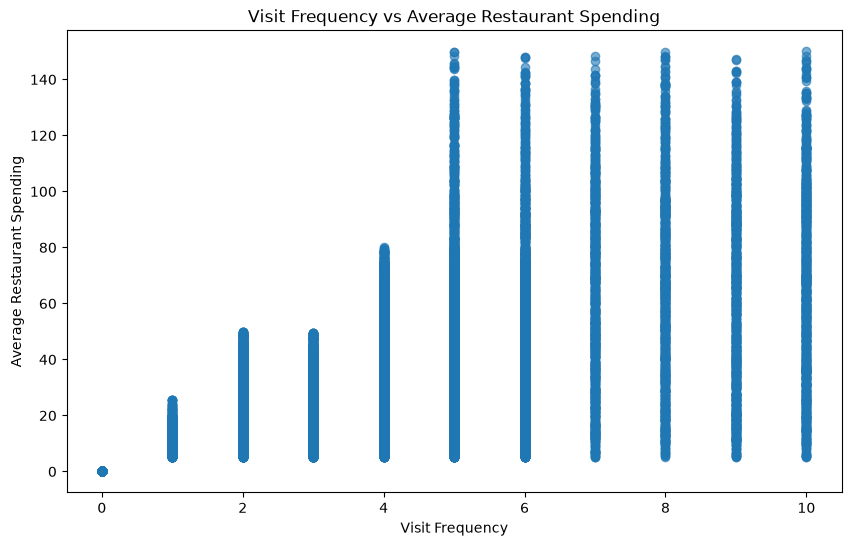

In [9]:
plt.figure(figsize=(10,6))

plt.scatter(
    customers_clean_df["frecuencia_visita"],
    customers_clean_df["promedio_gasto_comida"],
    alpha=0.6
)

plt.title("Visit Frequency vs Average Restaurant Spending")
plt.xlabel("Visit Frequency")
plt.ylabel("Average Restaurant Spending")

plt.show()

# Relationship Between Visit Frequency and Average Restaurant Spending

## Business Question

Is there a relationship between visit frequency and average restaurant spending?

## Business Value

Analyzing the relationship between visit frequency and average spending helps determine whether customers who visit the restaurant more often also tend to spend more money. This information can support the design of loyalty programs, personalized promotions, and customer retention strategies. Additionally, it helps identify unusual customer behavior that may indicate data quality issues or opportunities for further business analysis.

## Visualization

The following scatter plot illustrates the relationship between customers' visit frequency and their average restaurant spending.

## Interpretation

The scatter plot does not show a strong relationship between visit frequency and average restaurant spending. Customers with higher visit frequencies display a wide range of spending behaviors, from very low to very high spending. This suggests that visiting the restaurant more often does not necessarily imply a higher average spending.

## Business Insight

Since visit frequency alone does not determine customer spending, the company should avoid designing loyalty programs based only on the number of visits. Instead, customer segmentation should consider both **visit frequency** and **average spending**.

Customers who visit frequently and spend more could be rewarded with premium loyalty programs or exclusive benefits to increase customer retention. Meanwhile, customers who visit frequently but spend less could be targeted with personalized promotions or cross-selling strategies aimed at increasing their average spending per visit.

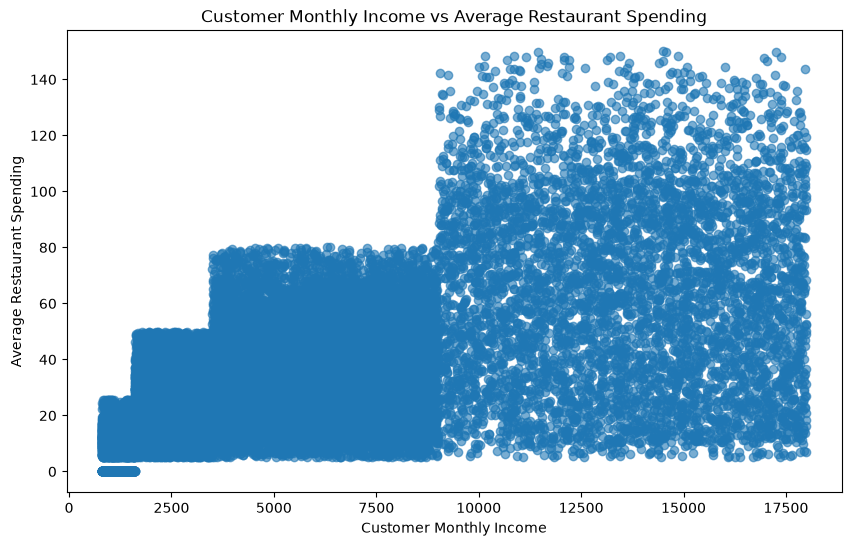

In [10]:
plt.figure(figsize=(10,6))

plt.scatter(
    customers_clean_df["ingresos_mensuales"],
    customers_clean_df["promedio_gasto_comida"],
    alpha=0.6
)

plt.title("Customer Monthly Income vs Average Restaurant Spending")
plt.xlabel("Customer Monthly Income")
plt.ylabel("Average Restaurant Spending")

plt.show()

# Relationship Between Monthly Income and Average Restaurant Spending

## Business Question

Is there a relationship between customers' monthly income and their average restaurant spending?

## Business Value

Understanding the relationship between customers' monthly income and their average restaurant spending helps determine whether purchasing power influences spending behavior. This information supports customer segmentation, personalized marketing campaigns, pricing strategies, and the development of products or promotions tailored to different income levels.

## Visualization

The following scatter plot illustrates the relationship between customers' monthly income and their average restaurant spending.

## Interpretation

The scatter plot suggests a positive relationship between customers' monthly income and their average restaurant spending. As monthly income increases, customers tend to have the potential to spend more on restaurant purchases. However, higher income does not necessarily guarantee higher spending, as considerable variability exists among customers with similar income levels.

Additionally, the stepped pattern observed in the scatter plot may indicate that the dataset was generated using predefined rules or spending limits rather than representing completely random real-world observations. This characteristic should be considered when interpreting the results.

## Business Insight

The company can segment its marketing strategies according to customers' monthly income levels. Higher-income customers may be targeted with premium products, exclusive promotions, or loyalty programs designed to maximize customer value. Meanwhile, customers with lower or medium income levels can receive more affordable offers, discounts, or personalized promotions that encourage increased restaurant spending while remaining aligned with their purchasing power.

### Statistical Summary

In [11]:
food_preferences_by_city = (
    customers_clean_df
    .groupby(
        ["ciudad_residencia", "preferencias_alimenticias"]
    )
    .size()
    .unstack()
)

food_preferences_by_city

preferencias_alimenticias,Carnes,Mariscos,Otro,Pescado,Unknown,Vegano,Vegetariano
ciudad_residencia,,,,,,,
Boston,535,493,198,272,102,239,708
Chicago,1589,696,591,546,268,571,1123
Dallas,822,366,249,239,129,258,539
Denver,632,468,172,249,118,258,626
Houston,716,333,238,229,88,197,411
Miami,511,819,293,307,146,382,728
NYC,1513,799,396,436,200,588,837
Phoenix,416,209,154,200,76,155,301
San Diego,656,584,194,288,190,407,756


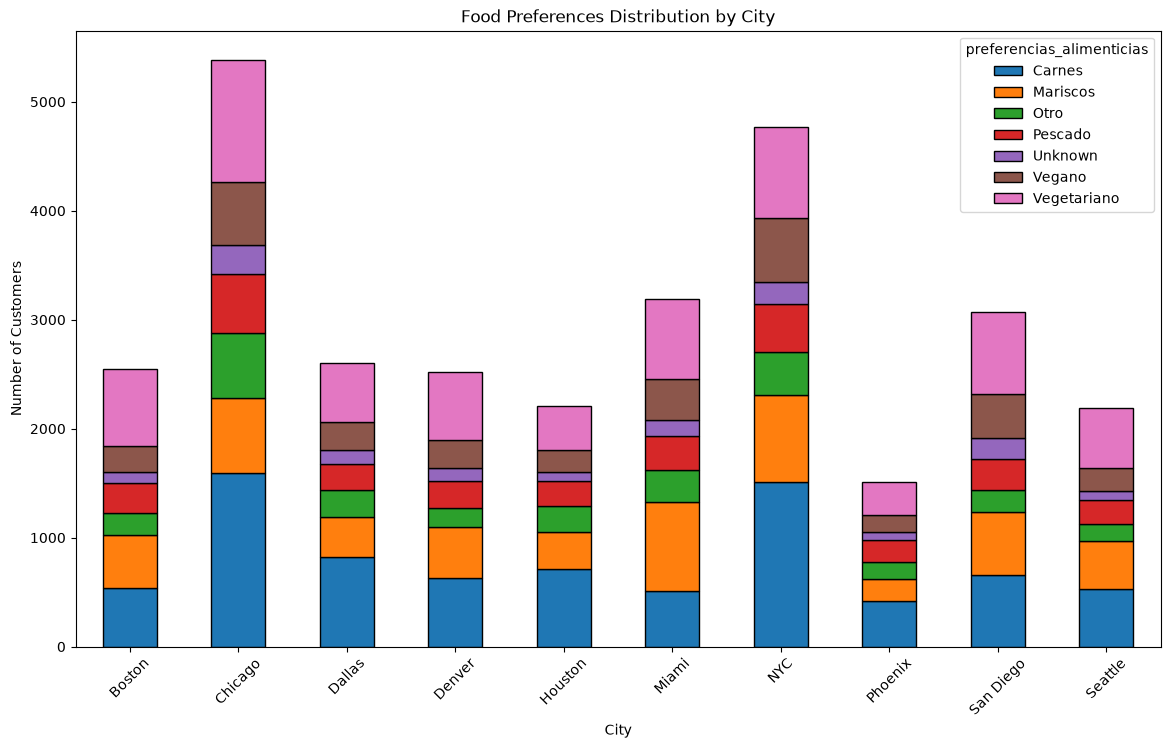

In [12]:
food_preferences_by_city.plot(
    kind="bar",
    stacked=True,
    figsize=(14,8),
    edgecolor="black"
)

plt.title("Food Preferences Distribution by City")
plt.xlabel("City")
plt.ylabel("Number of Customers")

plt.xticks(rotation=45)

plt.show()

# Food Preferences Distribution Across Cities

## Business Question

How are customers' food preferences distributed across different cities?

## Business Value

Understanding customers' food preferences across different cities helps the company identify regional consumption patterns and adapt its menu offerings or marketing strategies to local customer preferences. This information can also support personalized promotional campaigns, the introduction of new menu items, and cross-selling strategies that encourage customers to explore different food options.

## Visualization

The following stacked bar chart illustrates the distribution of customers' food preferences across different cities.

## Interpretation

The stacked bar chart shows that **Chicago** has the largest customer population, followed by **NYC**. Across most cities, meat-based dishes represent the most common food preference among customers. However, vegetarian food also accounts for a considerable proportion of customer preferences in nearly every city, suggesting that plant-based menu options remain an important market segment.

Additionally, some cities display different consumption patterns, indicating potential regional differences in customer food preferences.

## Business Insight

The company can use these findings to design region-specific marketing strategies and optimize its menu offerings according to customer preferences. Since meat-based dishes are the most popular across most cities, they should remain a key part of the menu and promotional campaigns.

However, the significant presence of vegetarian customers indicates that vegetarian menu options should continue to be expanded and promoted rather than treated as a niche offering.

Additionally, cities with a relatively larger seafood customer segment may represent an opportunity to introduce new seafood dishes, seasonal menus, or targeted promotional campaigns that align with local customer preferences.

In [13]:
high_spending_threshold = customers_clean_df["promedio_gasto_comida"].quantile(0.90)

high_spending_threshold

np.float64(68.09100000000002)

In [14]:
high_spending_customers = customers_clean_df[
    customers_clean_df["promedio_gasto_comida"] >= high_spending_threshold
]

In [15]:
high_spending_customers.head(20)

,id_persona,nombre,apellido,edad,genero,ciudad_residencia,estrato_socioeconomico,frecuencia_visita,promedio_gasto_comida,ocio,consume_licor,preferencias_alimenticias,membresia_premium,telefono_contacto,correo_electronico,tipo_de_pago_mas_usado,ingresos_mensuales
32,9148064715,Michael,Cochran,79.0,Masculino,Chicago,Muy Alto,8.0,78.02,No,Sí,Pescado,Sí,NaN,NaN,App,17625
38,3098578259,Michael,Patterson,60.0,Masculino,San Diego,Muy Alto,NaN,83.97,No,Sí,Carnes,Sí,NaN,david34@example.net,App,10814
44,4739304467,Russell,Ward,38.0,Masculino,Seattle,Muy Alto,10.0,78.55,No,Sí,Carnes,Sí,NaN,aaron31@example.org,Tarjeta,15741
47,6170452916,Bruce,Young,55.0,Masculino,Miami,Muy Alto,5.0,119.85,Sí,No,Carnes,Sí,NaN,ltran@example.com,Efectivo,15844
49,8077451214,April,Franco,30.0,Femenino,Miami,Alto,5.0,68.46,No,Sí,Mariscos,No,NaN,NaN,Efectivo,7298
56,4452595183,Allison,Graves,NaN,Femenino,NYC,Muy Alto,8.0,97.76,Sí,Sí,Vegetariano,Sí,682.599.2442x3506,brittanywalker@example.net,App,11228
77,8016841896,Seth,Cardenas,58.0,Masculino,San Diego,Muy Alto,7.0,69.71,No,No,Unknown,Sí,770-393-1957x996,NaN,App,13392
78,5256493527,Ashley,Ferrell,80.0,Femenino,NYC,Alto,5.0,69.43,No,No,Carnes,Sí,NaN,NaN,Tarjeta,4376
98,5841829810,Heather,Santiago,80.0,Femenino,Boston,Muy Alto,7.0,68.82,No,No,Mariscos,Sí,+1-819-758-1618x93298,NaN,Efectivo,10405
99,5798677148,Mary,Moran,53.0,Femenino,San Diego,Muy Alto,10.0,101.47,Sí,No,Carnes,Sí,NaN,thompsoncameron@example.org,Efectivo,16366


In [16]:
high_spending_customers["ingresos_mensuales"].mean()

np.float64(12221.887333333334)

In [17]:
high_spending_customers["frecuencia_visita"].mean()

np.float64(7.068070175438597)

In [18]:
high_spending_customers["preferencias_alimenticias"].value_counts()

preferencias_alimenticias
Carnes         790
Vegetariano    671
Mariscos       556
Vegano         318
Pescado        293
Otro           232
Unknown        140
Name: count, dtype: int64

In [19]:
high_spending_customers["membresia_premium"].value_counts()

membresia_premium
Sí    2723
No     277
Name: count, dtype: int64

In [20]:
high_spending_customers["genero"].value_counts()

genero
Femenino     1562
Masculino    1438
Name: count, dtype: int64

In [21]:
food_preferences = (
    high_spending_customers["preferencias_alimenticias"]
    .value_counts()
)

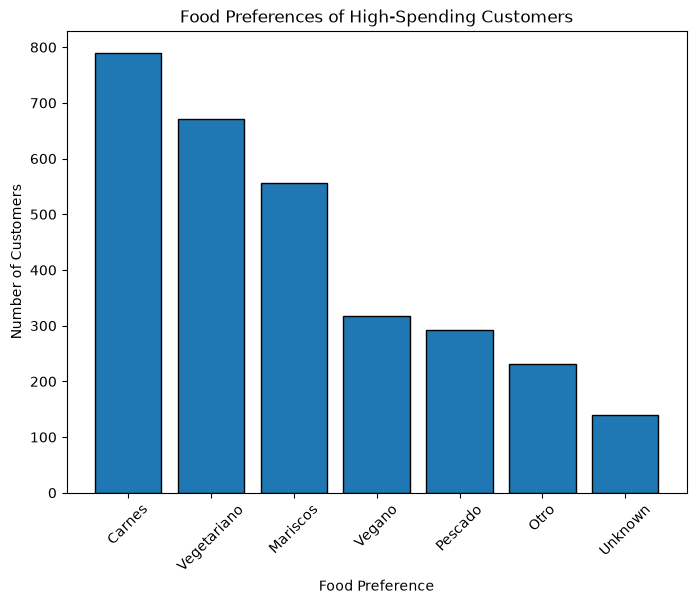

In [22]:
plt.figure(figsize=(8,6))

plt.bar(
    food_preferences.index,
    food_preferences.values,
    edgecolor="black"
)

plt.title("Food Preferences of High-Spending Customers")
plt.xlabel("Food Preference")
plt.ylabel("Number of Customers")

plt.xticks(rotation=45)

plt.show()

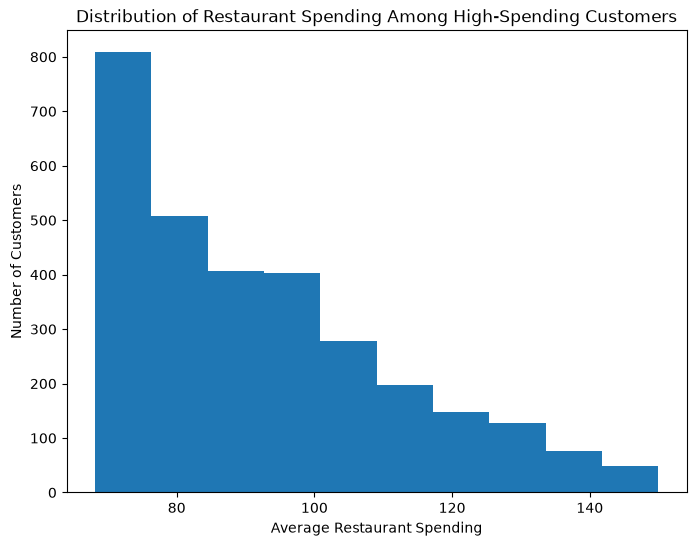

In [23]:
plt.figure(figsize=(8,6))

plt.hist(
    high_spending_customers["promedio_gasto_comida"],
    bins=10,
)

plt.title("Distribution of Restaurant Spending Among High-Spending Customers")
plt.xlabel("Average Restaurant Spending")
plt.ylabel("Number of Customers")

plt.show()

### Statistical Summary

In [24]:
premium_counts = (
    high_spending_customers["membresia_premium"]
    .value_counts()
)

premium_counts

membresia_premium
Sí    2723
No     277
Name: count, dtype: int64

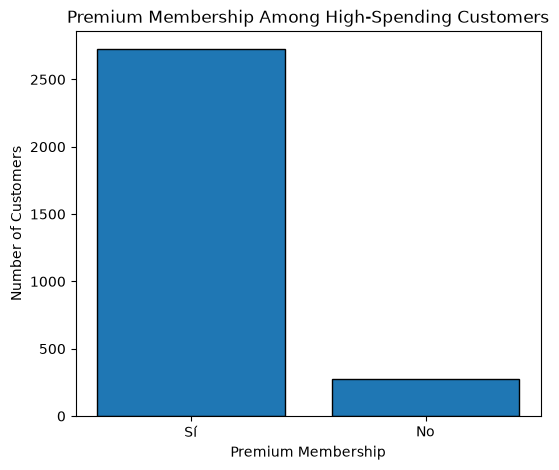

In [25]:
plt.figure(figsize=(6, 5))

plt.bar(
    premium_counts.index,
    premium_counts.values,
    edgecolor="black"
)

plt.title("Premium Membership Among High-Spending Customers")
plt.xlabel("Premium Membership")
plt.ylabel("Number of Customers")

plt.show()

# Profile of High Spending Customers

## Business Question

What are the characteristics of the highest spending customers? Specifically, what food preferences do they have, and how much do they typically spend on restaurant purchases?

## Business Value

Identifying the profile of the highest-spending customers helps the company understand which customers generate the greatest business value. This information can support the development of loyalty programs, personalized marketing campaigns, menu optimization, and customer retention strategies aimed at increasing long-term revenue.

## Visualization 1

### Food Preferences of High-Spending Customers

The following bar chart illustrates the food preferences of customers who belong to the top 10% of restaurant spending.

### Interpretation

The bar chart shows that **meat-based dishes** are the most popular food preference among the highest spending customers. However, **vegetarian** and **seafood** options also represent a significant portion of this customer segment, indicating that high-value customers have diverse food preferences rather than relying on a single type of cuisine

## Visualization 2

### Distribution of Restaurant Spending Among High-Spending Customers

The following histogram illustrates how restaurant spending is distributed among customers belonging to the highest-spending segment

### Interpretation

The histogram shows that most high-spending customers are concentrated in the lower range of the high spending segment, approximately between **68 and 80 monetary units**. As restaurant spending increases, the number of customers gradually decreases, indicating that only a small proportion of customers spend exceptionally high amounts

This distribution is positively skewed (right-skewed), suggesting that while many customers belong to the high-spending segment, only a few reach the highest spending levels

## Business Insight

The company can prioritize marketing campaigns and menu development around meat-based dishes, as they represent the most popular choice among high-value customers. At the same time, the considerable number of vegetarian and seafood customers suggests that these segments should not be overlooked

Additionally, the analysis reveals that **the vast majority of high-spending customers are Premium members**, indicating that the membership program is strongly associated with the company's highest-value customers. This finding suggests that the Premium program may play an important role in customer loyalty and long-term spending

Based on these findings, the company can strengthen its Premium membership program by offering exclusive rewards, personalized promotions, and premium dining experiences. Customers whose spending is close to the high-spending threshold may also be targeted with personalized campaigns designed to encourage them to become high-value customers

In [26]:
premium_memberships_by_city = (
    customers_clean_df
    .groupby(
        ["ciudad_residencia", "membresia_premium"]
    )
    .size()
    .unstack(fill_value=0)
)

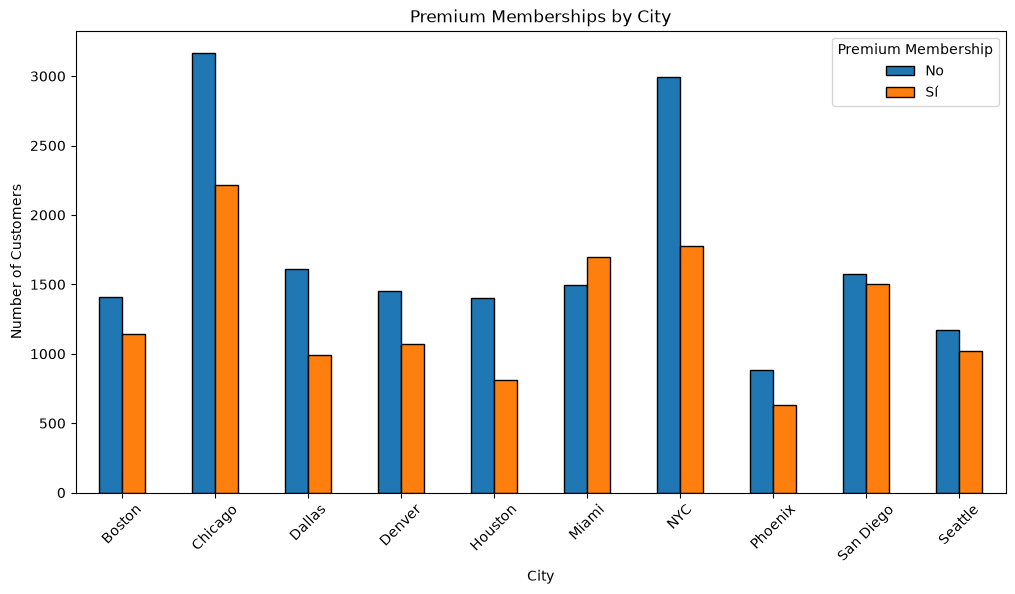

In [27]:
ax = premium_memberships_by_city.plot(
    kind="bar",
    figsize=(12,6),
    edgecolor="black"
)

ax.set_title("Premium Memberships by City")
ax.set_xlabel("City")
ax.set_ylabel("Number of Customers")

plt.xticks(rotation=45)

plt.legend(title="Premium Membership")

plt.show()

# Premium Memberships by City

## Business Question

Which city has the highest number of Premium memberships?

## Business Value

Understanding which cities have the largest number of Premium members helps the company identify where its membership program is performing best. This information can support regional marketing strategies, optimize membership campaigns, and help allocate resources more effectively to increase customer loyalty and long-term revenue

## Visualization

The following grouped bar chart compares the number of Premium and non-Premium customers across different cities

## Interpretation

The grouped bar chart shows that **Chicago has the highest number of Premium members**, followed closely by **NYC** and **Miami**. These cities also have the largest number of customers without a Premium membership, reflecting their larger customer populations

Overall, the visualization indicates that cities with larger customer bases also tend to have a greater number of Premium memberships

## Business Insight

The company can prioritize Premium membership marketing campaigns in cities such as **Chicago**, **NYC**, and **Miami**, where the customer base is already large. Increasing the conversion of existing non-Premium customers into Premium members in these cities could significantly improve customer loyalty and long-term revenue

Furthermore, analyzing the factors that contribute to the success of the Premium program in these cities may help replicate similar strategies in cities with lower membership adoption

In [28]:
customers_clean_df["consume_licor"].head()

0    No
1    Sí
2    Sí
3    Sí
4    No
Name: consume_licor, dtype: str

In [29]:
customers_clean_df["consume_licor"].value_counts()

consume_licor
Sí    18483
No    11517
Name: count, dtype: int64

In [30]:
customers_clean_df["grupo_edad"] = pd.cut(
    customers_clean_df["edad"],
    bins=[18, 25, 35, 45, 55, 65, 80],
    labels=[
        "18-25",
        "26-35",
        "36-45",
        "46-55",
        "56-65",
        "66-80"
    ],
    include_lowest=True
)

customers_clean_df["grupo_edad"].value_counts()

grupo_edad
66-80    7033
26-35    4805
46-55    4783
36-45    4761
56-65    4609
18-25    3701
Name: count, dtype: int64

### Statistical Summary

In [31]:
alcohol_by_age = (
    customers_clean_df
    .groupby(
        ["grupo_edad", "consume_licor"]
    )
    .size()
    .unstack(fill_value=0)
)

alcohol_by_age

consume_licor,No,Sí
grupo_edad,,
18-25,367,3334
26-35,1412,3393
36-45,2370,2391
46-55,2335,2448
56-65,1405,3204
66-80,3474,3559


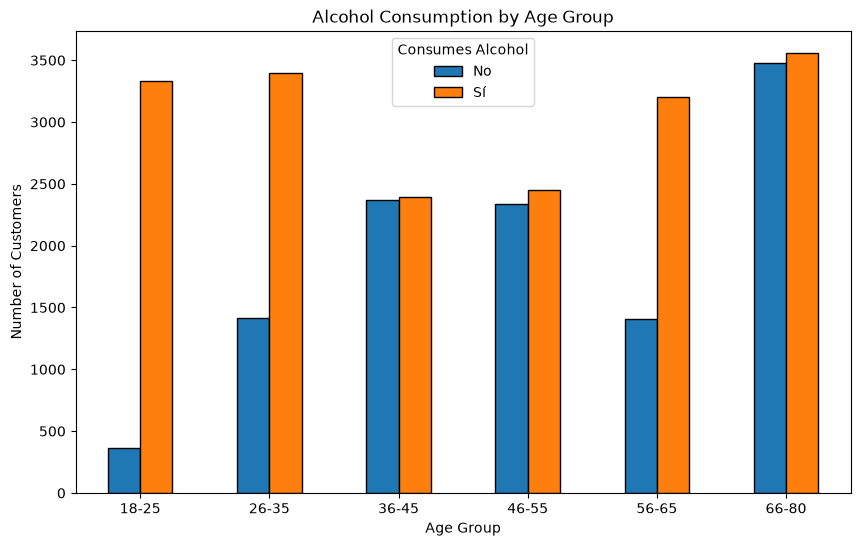

In [32]:
ax = alcohol_by_age.plot(
    kind="bar",
    figsize=(10,6),
    edgecolor="black"
)

ax.set_title("Alcohol Consumption by Age Group")
ax.set_xlabel("Age Group")
ax.set_ylabel("Number of Customers")

plt.xticks(rotation=0)

plt.legend(title="Consumes Alcohol")

plt.show()

# Alcohol Consumption by Age Group

## Business Question

Is there a relationship between customer age and alcohol consumption in restaurants?

## Business Value

Understanding the relationship between customer age and alcohol consumption helps the company identify consumption patterns across different age groups. These insights can support the design of targeted marketing campaigns, personalized promotions, and beverage offerings adapted to different customer segments

Additionally, this analysis helps verify compliance with business rules and legal requirements, ensuring that alcohol consumption is only associated with customers who meet the minimum legal drinking age

## Visualization

The following grouped bar chart compares alcohol consumption across different customer age groups

## Interpretation

The grouped bar chart shows that customers aged **18–35** have a noticeably higher proportion of alcohol consumers than non-consumers. In the **36–55** age groups, alcohol consumption and non-consumption become much more balanced, indicating a more even distribution between both groups

Among customers aged **66–80**, both alcohol consumers and non-consumers represent the largest customer population, with very similar counts, suggesting that alcohol consumption remains common even among older customers

## Business Insight

The company can develop age-specific marketing campaigns by promoting alcoholic beverages to customer segments where alcohol consumption is more common, particularly among younger adults. At the same time, restaurants should continue offering attractive non-alcoholic alternatives, such as mocktails and specialty beverages, to engage customers who do not consume alcohol

Providing diverse beverage options allows the business to serve different customer preferences while maximizing customer satisfaction and creating a more inclusive dining experience

# Final Conclusions

This exploratory analysis provided valuable insights into customer behavior across multiple cities.

The analysis revealed significant differences in customer distribution, restaurant spending, food preferences, premium membership adoption, and alcohol consumption patterns.

Among all cities, **Chicago** was selected for further analysis due to its large customer base and high number of Premium members. This decision supported the integration with external restaurant information obtained through the Yelp Fusion API in Advance 2.

Overall, the results demonstrate how customer segmentation and behavioral analysis can support data-driven business decisions related to marketing, customer retention, pricing strategies, and restaurant recommendations.